In [48]:
#definições
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
DATABASE_PATH = Path("../data/outputs/result_test_500_ficticias.csv")

In [49]:
#visualização
df = pd.read_csv(DATABASE_PATH)
df.head()

,date,description_raw,description_normalized,amount_cents,signed_amount_cents,direction,transaction_type,balance_after_cents,doc_number,transaction_code,source_page,source_text,extraction_method,warnings,review_required,category
0,2025-01-01,"1.548,85 (+) 64207 700000000000163 Dep dinheir...",Dep dinheiro ATM 01/01 12:50 CENTRO,154885,154885,credit,deposito,404885,700000000000163,64207,1,"1.548,85 (+) 64207 700000000000163 Dep dinheir...",synthetic,NaN,False,deposito
1,2025-01-02,"94,23 (-) 13015 700000000001154 Pix - Enviado ...",Pix - Enviado 02/01 16:58 MANUTENÇÃO E OFICINA,-9423,-9423,debit,pix,395462,700000000001154,13015,1,"94,23 (-) 13015 700000000001154 Pix - Enviado ...",synthetic,NaN,False,manutenção
2,2025-01-03,"373,74 (-) 53369 700000000002066 Pix - Enviado...",Pix - Enviado 03/01 11:27 PARCELA DE FINANCIAM...,-37374,-37374,debit,pix,358088,700000000002066,53369,1,"373,74 (-) 53369 700000000002066 Pix - Enviado...",synthetic,NaN,False,financeamento
3,2025-01-05,"558,20 (-) 69535 700000000003755 Pix - Enviado...",Pix - Enviado 05/01 07:27 PAGAMENTO DE MULTA,-55820,-55820,debit,pix,302268,700000000003755,69535,1,"558,20 (-) 69535 700000000003755 Pix - Enviado...",synthetic,NaN,False,multas
4,2025-01-06,"708,13 (-) 22742 700000000004844 Pix - Enviado...",Pix - Enviado 06/01 22:43 MANUTENÇÃO E OFICINA,-70813,-70813,debit,pix,231455,700000000004844,22742,1,"708,13 (-) 22742 700000000004844 Pix - Enviado...",synthetic,NaN,False,manutenção


In [50]:
#descartar colunas inuteis

df = df.drop(columns=[
    "date",
    "description_raw", 
    "amount_cents",
    "doc_number", 
    "transaction_code", 
    "source_text", 
    "source_page",
    "extraction_method",
    "balance_after_cents", 
    "warnings"])

df.head()

,description_normalized,signed_amount_cents,direction,transaction_type,review_required,category
0,Dep dinheiro ATM 01/01 12:50 CENTRO,154885,credit,deposito,False,deposito
1,Pix - Enviado 02/01 16:58 MANUTENÇÃO E OFICINA,-9423,debit,pix,False,manutenção
2,Pix - Enviado 03/01 11:27 PARCELA DE FINANCIAM...,-37374,debit,pix,False,financeamento
3,Pix - Enviado 05/01 07:27 PAGAMENTO DE MULTA,-55820,debit,pix,False,multas
4,Pix - Enviado 06/01 22:43 MANUTENÇÃO E OFICINA,-70813,debit,pix,False,manutenção


In [51]:
#remover duplicatas
df = df.drop_duplicates()
df.head()

,description_normalized,signed_amount_cents,direction,transaction_type,review_required,category
0,Dep dinheiro ATM 01/01 12:50 CENTRO,154885,credit,deposito,False,deposito
1,Pix - Enviado 02/01 16:58 MANUTENÇÃO E OFICINA,-9423,debit,pix,False,manutenção
2,Pix - Enviado 03/01 11:27 PARCELA DE FINANCIAM...,-37374,debit,pix,False,financeamento
3,Pix - Enviado 05/01 07:27 PAGAMENTO DE MULTA,-55820,debit,pix,False,multas
4,Pix - Enviado 06/01 22:43 MANUTENÇÃO E OFICINA,-70813,debit,pix,False,manutenção


In [52]:
#remover nulos
df = df.dropna(axis=0, inplace=False)
df.head()

,description_normalized,signed_amount_cents,direction,transaction_type,review_required,category
0,Dep dinheiro ATM 01/01 12:50 CENTRO,154885,credit,deposito,False,deposito
1,Pix - Enviado 02/01 16:58 MANUTENÇÃO E OFICINA,-9423,debit,pix,False,manutenção
2,Pix - Enviado 03/01 11:27 PARCELA DE FINANCIAM...,-37374,debit,pix,False,financeamento
3,Pix - Enviado 05/01 07:27 PAGAMENTO DE MULTA,-55820,debit,pix,False,multas
4,Pix - Enviado 06/01 22:43 MANUTENÇÃO E OFICINA,-70813,debit,pix,False,manutenção


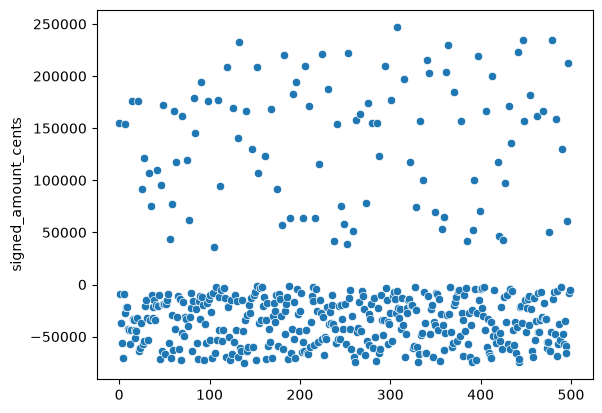

In [53]:
#identificação de outliers da variavel numerica

sns.scatterplot(x=range(len(df['signed_amount_cents'])), y=df['signed_amount_cents'])
plt.show()


In [54]:
from scipy import stats

df['z_score'] = stats.zscore(df['signed_amount_cents'])

outliers = df[abs(df['z_score']) > 3]

outliers.head()

,description_normalized,signed_amount_cents,direction,transaction_type,review_required,category,z_score
308,Transferência recebida 23/03 09:52 PAGAMENTO D...,247486,credit,transferencia,False,pagamento,3.162045
447,Dep dinheiro ATM 11/10 11:34 CENTRO,234921,credit,deposito,False,deposito,3.001445
479,Pix - Recebido 26/11 21:00 PLATAFORMA DE CORRIDAS,234931,credit,pix,False,ganho de corrida,3.001573


In [55]:
#dataframe sem outliers
df = df[abs(df['z_score']) < 3]

df = df.drop(columns='z_score')
df.head()

,description_normalized,signed_amount_cents,direction,transaction_type,review_required,category
0,Dep dinheiro ATM 01/01 12:50 CENTRO,154885,credit,deposito,False,deposito
1,Pix - Enviado 02/01 16:58 MANUTENÇÃO E OFICINA,-9423,debit,pix,False,manutenção
2,Pix - Enviado 03/01 11:27 PARCELA DE FINANCIAM...,-37374,debit,pix,False,financeamento
3,Pix - Enviado 05/01 07:27 PAGAMENTO DE MULTA,-55820,debit,pix,False,multas
4,Pix - Enviado 06/01 22:43 MANUTENÇÃO E OFICINA,-70813,debit,pix,False,manutenção


In [56]:
#verificar desbalanceamento de classes

df_categorias = (df.groupby('category').size().reset_index(name="quantidade"))
df_categorias.head(20)

,category,quantidade
0,acessórios,26
1,alimentação,33
2,celular/chip,38
3,cnh,20
4,combustivel,41
5,deposito,39
6,financeamento,29
7,ganho de corrida,26
8,ipva,31
9,lavagem,35


In [65]:
#separação dos dados para o treinamento da arvore de decisão e treinamento do modelo
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

target = "category"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)


In [78]:
preprocessador = ColumnTransformer(
    transformers=[
        (
            "texto",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                ngram_range=(1, 2),
                min_df=2,
                max_features=5000
            ),
            "description_normalized"
        ),
        (
            "numericas",
            "passthrough",
            ["signed_amount_cents"]
        ),
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            ["direction","transaction_type"]
        )
    ],
    remainder="drop"
)

In [79]:
#modelo de arvore de decisao
modelo = Pipeline([
    ("preprocessador", preprocessador),

    ("arvore", DecisionTreeClassifier(
        criterion="gini",
        max_depth=7,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

In [80]:
#separação dos dados 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
#treinamento
modelo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessador', ...), ('arvore', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](16,)","['acessórios','alimentação','celular/chip',...,'pagamento', 'pedagio e estacionamento','seguro']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['description_normalized','signed_amount_cents','direction', 'transaction_type','review_required']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('texto', ...), ('numericas', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and com

In [82]:
#analise das previsões
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = modelo.predict(X_test)

print(f"Accuracy:{accuracy_score(y_test, y_pred)}")
print(f"F1 Score:{f1_score(y_test, y_pred, average="weighted")}")
print(classification_report(y_test, y_pred))

Accuracy:0.53
F1 Score:0.4703174603174603
                          precision    recall  f1-score   support

              acessórios       1.00      1.00      1.00         5
             alimentação       1.00      1.00      1.00         7
            celular/chip       1.00      1.00      1.00         8
                     cnh       0.00      0.00      0.00         4
             combustivel       1.00      1.00      1.00         8
                deposito       0.15      1.00      0.25         8
           financeamento       1.00      1.00      1.00         6
        ganho de corrida       1.00      1.00      1.00         5
                    ipva       0.00      0.00      0.00         6
                 lavagem       0.00      0.00      0.00         7
              manutenção       0.00      0.00      0.00         7
                  multas       1.00      1.00      1.00         6
                  outros       0.00      0.00      0.00         5
               pagamento       0.

c:\finance-class\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\finance-class\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\finance-class\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [85]:
#testanto parametros diferentes para o modelo 
from sklearn.model_selection import GridSearchCV, StratifiedKFold

parametros = {
    "arvore__criterion": ["gini", "entropy", "log_loss"],
    "arvore__max_depth": [3, 5, 7, 10, 15, None],
    "arvore__min_samples_split": [2, 5, 10, 20],
    "arvore__min_samples_leaf": [1, 2, 5, 10],
    "arvore__max_features": [None, "sqrt", "log2"],
    "arvore__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

busca = GridSearchCV(
    estimator=modelo,
    param_grid=parametros,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

busca.fit(X_train, y_train)
#Novo treinamento

print("Melhores parâmetros:")
print(busca.best_params_)

print("Melhor F1 médio na validação:")
print(busca.best_score_)

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
Melhores parâmetros:
{'arvore__class_weight': None, 'arvore__criterion': 'gini', 'arvore__max_depth': 15, 'arvore__max_features': None, 'arvore__min_samples_leaf': 1, 'arvore__min_samples_split': 2}
Melhor F1 médio na validação:
1.0


In [88]:
#Teste do melhor modelo

melhor_arvore = busca.best_estimator_

y_pred_best = melhor_arvore.predict(X_test)

print("Acuracy:", accuracy_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best, average="weighted"))

print(classification_report(y_test, y_pred))

Acuracy: 1.0
F1: 1.0
                          precision    recall  f1-score   support

              acessórios       1.00      1.00      1.00         5
             alimentação       1.00      1.00      1.00         7
            celular/chip       1.00      1.00      1.00         8
                     cnh       0.00      0.00      0.00         4
             combustivel       1.00      1.00      1.00         8
                deposito       0.15      1.00      0.25         8
           financeamento       1.00      1.00      1.00         6
        ganho de corrida       1.00      1.00      1.00         5
                    ipva       0.00      0.00      0.00         6
                 lavagem       0.00      0.00      0.00         7
              manutenção       0.00      0.00      0.00         7
                  multas       1.00      1.00      1.00         6
                  outros       0.00      0.00      0.00         5
               pagamento       0.00      0.00      0.0

c:\finance-class\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\finance-class\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\finance-class\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [89]:
#testando modelo svm

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline: normalização + SVM
pipeline = Pipeline([
    ("preprocessador", preprocessador),
    ("svm", SVC())
])

# Hiperparâmetros a serem testados
parametros = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__class_weight": [None, "balanced"]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
        "svm__class_weight": [None, "balanced"]
    }
]

# Busca pelas melhores combinações
busca_svm = GridSearchCV(
    estimator=pipeline,
    param_grid=parametros,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Treinamento
busca_svm.fit(X_train, y_train)

print("Melhores parâmetros:")
print(busca_svm.best_params_)

print("Melhor F1 Macro na validação:")
print(busca_svm.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [ ]:
melhor_modelo_svm = busca_svm.best_estimator_

y_pred_svm = melhor_modelo_svm.predict(X_test)

print("Acuracy:", accuracy_score(y_test, y_pred_svm))
print("F1 Macro:", f1_score(y_test, y_pred_svm, average="macro"))

print(classification_report(y_test, y_pred_svm))

Acuracy: 0.28
F1 Macro: 0.19886363636363635
                          precision    recall  f1-score   support

              acessórios       0.00      0.00      0.00         5
             alimentação       0.00      0.00      0.00         7
            celular/chip       0.00      0.00      0.00         8
                     cnh       0.00      0.00      0.00         4
             combustivel       0.10      1.00      0.18         8
                deposito       1.00      1.00      1.00         8
           financeamento       0.00      0.00      0.00         6
        ganho de corrida       1.00      1.00      1.00         5
                    ipva       0.00      0.00      0.00         6
                 lavagem       0.00      0.00      0.00         7
              manutenção       0.00      0.00      0.00         7
                  multas       0.00      0.00      0.00         6
                  outros       0.00      0.00      0.00         5
               pagamento       

c:\finance-class\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\finance-class\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\finance-class\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
